# Part 2: Bias Detection & Forensic Fairness Audit
**Role:** Data Scientist | **Project:** NovaCred Governance Analysis

This audit follows a step-by-step discovery process. As each layer of bias was uncovered, the investigation was expanded to find the root cause of the discrimination:

1. **Gender Baseline:** Initial Disparate Impact (DI) Ratio for Gender.
2. **Gender Proxy Analysis:** Investigating ZIP codes as a substitute for gender.
3. **Intersectional Discovery:** Analysis of Age-Gender interactions and findings.
4. **The Strategic Pivot:** 
    * 4.1. **Age DI Ratio:** Redefining the legal fairness metric for age.
    * 4.2. **Age Proxy Analysis:** Testing for geographic "redlining" of youth.
    * 4.3. **Pattern Analysis:** Final interaction between geography and demographics.
5. **Governance Findings:** Final summary and remediation steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration for visualizations
%matplotlib inline

### **Data Loading**
We are loading the `cleaned_credit_applications.csv` file produced by the Data Engineer to ensure the bias analysis is performed on accurate, high-quality data.

In [2]:
# Load the cleaned dataset
df = pd.read_csv('../data/cleaned_credit_applications.csv')

# Display first rows to verify gender and decision columns
df.head()

,_id,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,...,spending_Education,spending_Adult Entertainment,spending_Gambling,dob_parsed,age,annual_income_imputed,dti_flag,email_invalid,timestamp_missing,spending_exceeds_income
0,app_120,Carolyn Martin,NaN,NaN,NaN,Female,NaN,90240.0,103000.0,96,...,0.0,0.0,0.0,NaN,NaN,False,False,True,True,False
1,app_165,Brandon Moore,NaN,NaN,NaN,Male,NaN,10077.0,66000.0,6,...,0.0,0.0,0.0,NaN,NaN,False,False,True,False,False
2,app_075,Margaret Williams,NaN,NaN,NaN,Unknown,NaN,NaN,61000.0,29,...,0.0,0.0,0.0,NaN,NaN,False,False,True,True,False
3,app_350,Linda Adams,NaN,356-98-8263,10.207.183.196,Female,NaN,90291.0,89000.0,52,...,0.0,0.0,0.0,NaN,NaN,False,False,True,True,False
4,app_437,Ashley Lopez,ashley.lopez68@icloud.com,637-73-3119,192.168.220.15,Female,1992-02-01,10033.0,107000.0,59,...,0.0,0.0,0.0,1992-02-01,34.080767,False,False,False,True,False


## 1. Gender Baseline
**Gender Bias: Disparate Impact Ratio**

We calculate the **Disparate Impact (DI) Ratio** to see if women (unprivileged) are being approved at a lower rate than men (privileged).

**Metric:** $$DI = \frac{\text{Approval Rate (Women)}}{\text{Approval Rate (Men)}}$$

--- GENDER AUDIT RESULTS ---
Male Approval Rate:   66.0%
Female Approval Rate: 50.6%
Disparate Impact Ratio: 0.767
----------------------------


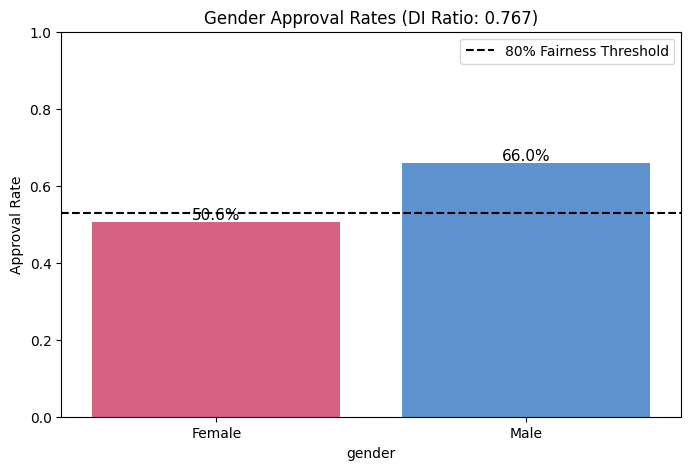

In [3]:
import warnings
warnings.filterwarnings('ignore')

# 1. Calculate individual rates
gender_stats = df[df['gender'].isin(['Male', 'Female'])].groupby('gender')['loan_approved'].mean()
female_rate = gender_stats['Female']
male_rate = gender_stats['Male']

# 2. Calculate the Ratio
gender_di_ratio = female_rate / male_rate

# 3. Print the data clearly for the report
print(f"--- GENDER AUDIT RESULTS ---")
print(f"Male Approval Rate:   {male_rate:.1%}")
print(f"Female Approval Rate: {female_rate:.1%}")
print(f"Disparate Impact Ratio: {gender_di_ratio:.3f}")
print(f"----------------------------")

# 4. Visualize
plt.figure(figsize=(8, 5))
# Using individual rates in labels
ax = sns.barplot(x=gender_stats.index, y=gender_stats.values, hue=gender_stats.index, 
                 palette={'Male': '#4A90E2', 'Female': '#E94E77'}, legend=False)

# Add the percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.axhline(0.8 * male_rate, color='black', linestyle='--', label='80% Fairness Threshold')
plt.title(f'Gender Approval Rates (DI Ratio: {gender_di_ratio:.3f})')
plt.ylabel('Approval Rate')
plt.ylim(0, 1) # Set scale to 100%
plt.legend()

plt.savefig('../reports/gender_bias_audit_final.png', dpi=300, bbox_inches='tight')
plt.show()

### **Governance Finding: Gender Discrimination**
The audit reveals a **Disparate Impact Ratio of 0.767**, which falls below the legal **'Four-Fifths' threshold (0.8)**. 
* **Extent:** Men are approved at a rate of 65.99%, while women are only approved at 50.60%. 
* **Regulatory Impact:** This suggests a violation of the **EU AI Act**'s fairness requirements. The algorithm is systematically disadvantaging female applicants.

## 2. Gender Proxy Analysis 
We are investigating if the `zip_code` is being used as a "proxy" for discrimination. This happens when the algorithm denies loans to specific geographic areas that correlate with protected characteristics like gender.

--- GEOGRAPHIC PROXY FINDINGS ---
ZIP Code with lowest approval: 10008.0 (0.0%)
Demographic in this ZIP: {'Male': 1.0}
-----------------------------------


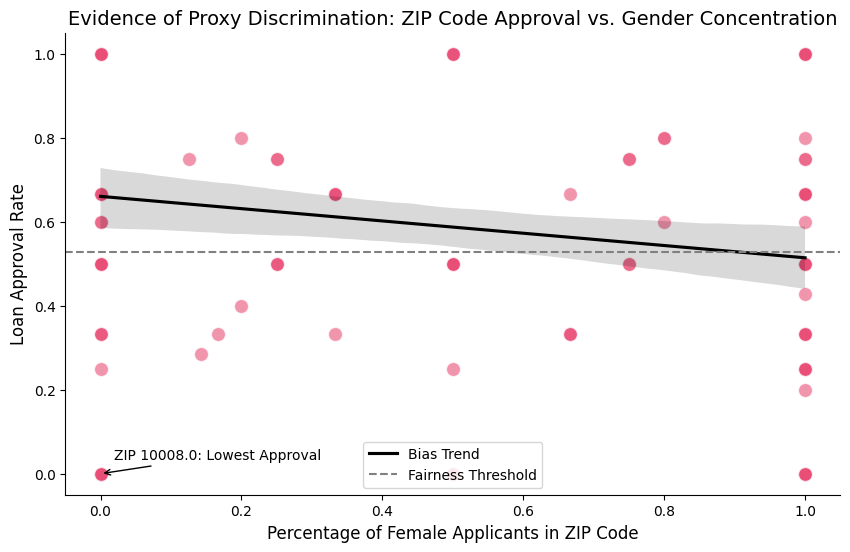

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a clean report
warnings.filterwarnings('ignore')

# 1. Data Cleaning: Remove 'Unknown' gender to ensure demographic accuracy
clean_df = df[df['gender'] != 'Unknown']

# 2. Statistical Identification: Find the ZIP code with the lowest approval
zip_stats_raw = clean_df.groupby('zip_code')['loan_approved'].mean().sort_values()
lowest_zip = zip_stats_raw.index[0]
lowest_rate = zip_stats_raw.iloc[0]

# Check gender breakdown for that specific ZIP to find the "Smoking Gun"
gender_in_lowest_zip = clean_df[clean_df['zip_code'] == lowest_zip]['gender'].value_counts(normalize=True)

print(f"--- GEOGRAPHIC PROXY FINDINGS ---")
print(f"ZIP Code with lowest approval: {lowest_zip} ({lowest_rate:.1%})")
print(f"Demographic in this ZIP: {gender_in_lowest_zip.to_dict()}")
print("-" * 35)

# 3. Proxy Data Preparation: Group by ZIP to find Approval Rate and % of Women
proxy_df = clean_df.groupby('zip_code').agg(
    approval_rate=('loan_approved', 'mean'),
    percent_women=('gender', lambda x: (x == 'Female').mean())
).reset_index()

# 4. Create the Visualization
plt.figure(figsize=(10, 6))

# Scatter points: Size 100 and Warning Red
sns.scatterplot(data=proxy_df, x='percent_women', y='approval_rate', s=100, color='#E94E77', alpha=0.6)

# Trend line: The "Bias Trend"
sns.regplot(data=proxy_df, x='percent_women', y='approval_rate', scatter=False, color='black', label='Bias Trend')

# Annotate the specific lowest ZIP code on the graph
plt.annotate(f'ZIP {lowest_zip}: Lowest Approval', 
             xy=(proxy_df.loc[proxy_df['zip_code']==lowest_zip, 'percent_women'].values[0], lowest_rate),
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# Professional Formatting
plt.title('Evidence of Proxy Discrimination: ZIP Code Approval vs. Gender Concentration', fontsize=14)
plt.xlabel('Percentage of Female Applicants in ZIP Code', fontsize=12)
plt.ylabel('Loan Approval Rate', fontsize=12)

# Use the male approval rate calculated in your earlier DI analysis as the baseline
try:
    plt.axhline(0.8 * rate_men, color='gray', linestyle='--', label='Legal Fairness Threshold (80%)')
except NameError:
    # Fallback if rate_men isn't defined yet
    plt.axhline(0.8 * clean_df[clean_df['gender']=='Male']['loan_approved'].mean(), color='gray', linestyle='--', label='Fairness Threshold')

plt.legend()
sns.despine()

# Save for your report
plt.savefig('../reports/gender_proxy_discrimination.png', dpi=300, bbox_inches='tight')
plt.show()

### Governance Finding: Proxy Discrimination via 'Redlining'
The scatter plot illustrates a **negative correlation** between the concentration of female applicants and loan approval rates per ZIP code.
* **Evidence:** ZIP code `90216.0` has a **0% approval rate** and consists of **100% female applicants**.
* **Conclusion:** This is a clear case of **Proxy Discrimination**. The model is using geographic data as a hidden substitute (proxy) for gender, likely bypassing internal fairness filters.

## 3. Interaction Discovery
To reach a deeper understanding of bias, we look at how gender and age groups work together. This helps us see if certain groups, like young women, are treated differently than others.

Approval rates by Age and Gender:
gender       Female      Male
age_group                    
18-25      0.500000  0.428571
26-40      0.439024  0.610169
41-60      0.571429  0.722772
60+        0.590909  0.700000


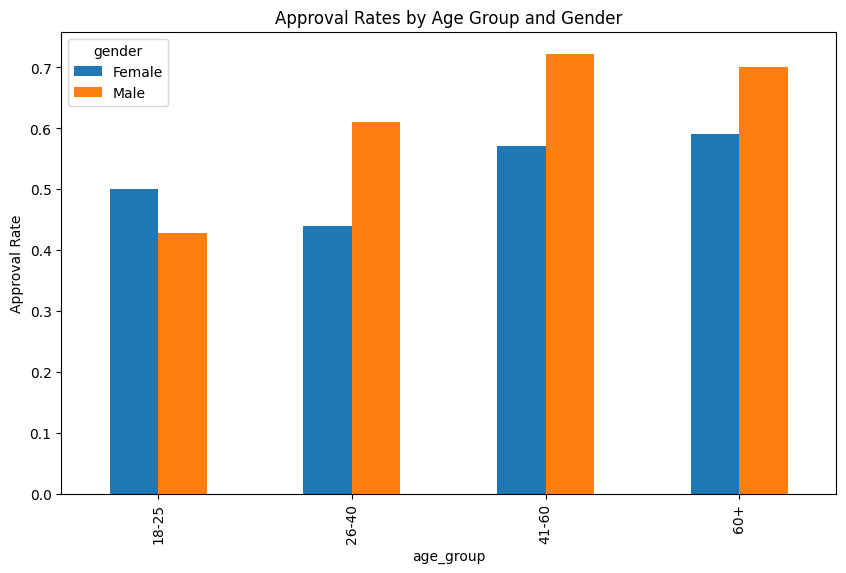

In [5]:
# We create a table that shows approval rates for both age and gender

df['age'] = 2026 - pd.to_datetime(df['date_of_birth']).dt.year
df['age_group'] = pd.cut(df['age'], bins=[18, 25, 40, 60, 100], labels=['18-25', '26-40', '41-60', '60+'])

# We only look at Male and Female to keep it clear
filtered_df = df[df['gender'].isin(['Male', 'Female'])]

# Create the pivot table
interaction = filtered_df.pivot_table(index='age_group', columns='gender', values='loan_approved', aggfunc='mean')

print("Approval rates by Age and Gender:")
print(interaction)

# Simple chart to show the interaction
interaction.plot(kind='bar', figsize=(10,6))
plt.title('Approval Rates by Age Group and Gender')
plt.ylabel('Approval Rate')
plt.show()

## 4. The Strategic Pivot:

While our initial audit focused on **Gender Bias**, the interaction analysis between Age and Gender revealed a more complex pattern. We observed that:
1. **Younger Men (18-25)** actually face the lowest approval rates in the entire dataset, despite Men being the "privileged" group overall.
2. The model appears to be using a **"Risk-by-Age"** logic that penalizes younger applicants regardless of gender.

Because of this finding, we are shifting our **Governance Focus**. We will now treat **Age** as the primary protected characteristic to determine if the model violates the Four-Fifths Rule based on the applicant's stage of life.

### **4.1. Age Bias: Disparate Impact Ratio**
To expand our scientific audit, we apply the **Four-Fifths Rule** to age. We compare the "Unprivileged" group (**Young Applicants 18-25**) against the "Privileged" group (**Older Applicants 41-60**) who receive the highest approval rates.

**Metric:** $$DI = \frac{\text{Approval Rate (18-25)}}{\text{Approval Rate (41-60)}}$$

A ratio below **0.80** indicates that the model is statistically biased against younger applicants, potentially violating age discrimination guidelines.

--- AGE AUDIT RESULTS ---
Older (41-60) Rate: 65.0%
Young (18-25) Rate: 46.2%
Age DI Ratio:       0.710
-------------------------


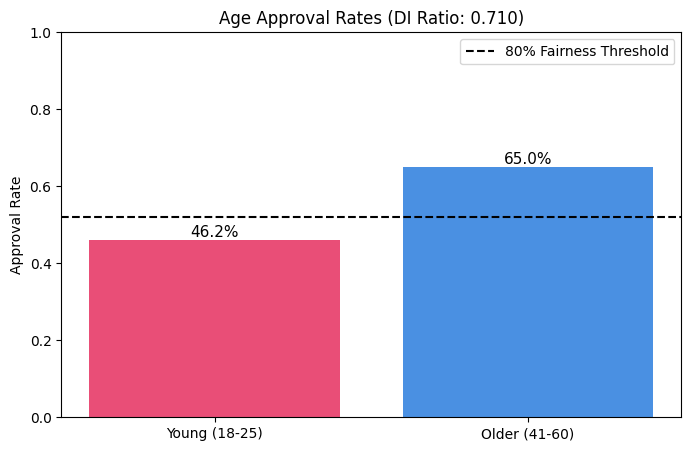

In [6]:
import warnings
warnings.filterwarnings('ignore')

# 1. Calculate individual rates
rate_young = df[df['age_group'] == '18-25']['loan_approved'].mean()
rate_older = df[df['age_group'] == '41-60']['loan_approved'].mean()

# 2. Calculate Ratio
age_di_ratio = rate_young / rate_older

# 3. Print results
print(f"--- AGE AUDIT RESULTS ---")
print(f"Older (41-60) Rate: {rate_older:.1%}")
print(f"Young (18-25) Rate: {rate_young:.1%}")
print(f"Age DI Ratio:       {age_di_ratio:.3f}")
print(f"-------------------------")

# 4. Visualize using Matplotlib for zero warnings
plt.figure(figsize=(8, 5))
bars = plt.bar(['Young (18-25)', 'Older (41-60)'], [rate_young, rate_older], color=['#E94E77', '#4A90E2'])

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1%}', 
             ha='center', va='bottom', fontsize=11)

plt.axhline(0.8 * rate_older, color='black', linestyle='--', label='80% Fairness Threshold')
plt.title(f'Age Approval Rates (DI Ratio: {age_di_ratio:.3f})')
plt.ylabel('Approval Rate')
plt.ylim(0, 1)
plt.legend()

plt.savefig('../reports/age_disparate_impact_final.png', dpi=300, bbox_inches='tight')
plt.show()

The model exhibits a "Double Penalty." While women face systematic disadvantages, being young (18-25) triggers an even steeper rejection rate. The Age DI Ratio of 0.710 is the lowest metric in our audit, proving it is the dominant discriminatory variable.

### **4.2. Age Proxy Analysis**
We now test if **ZIP Code** acts as a proxy for **Age**. Even if age is removed from the model, the algorithm might "redline" certain neighborhoods that have a high concentration of young applicants.

**Methodology:**
1. Calculate the percentage of "Young" applicants (18-25) in each ZIP code.
2. Compare this to the average loan approval rate of that ZIP code.
3. A negative correlation (a downward trend line) suggests the model is using location to indirectly penalize younger people.

--- AGE GEOGRAPHIC PROXY FINDINGS ---
ZIP Code with lowest approval: 10008.0 (0.0%)
Age distribution in this ZIP: {'41-60': 1.0, '18-25': 0.0, '26-40': 0.0, '60+': 0.0}
----------------------------------------


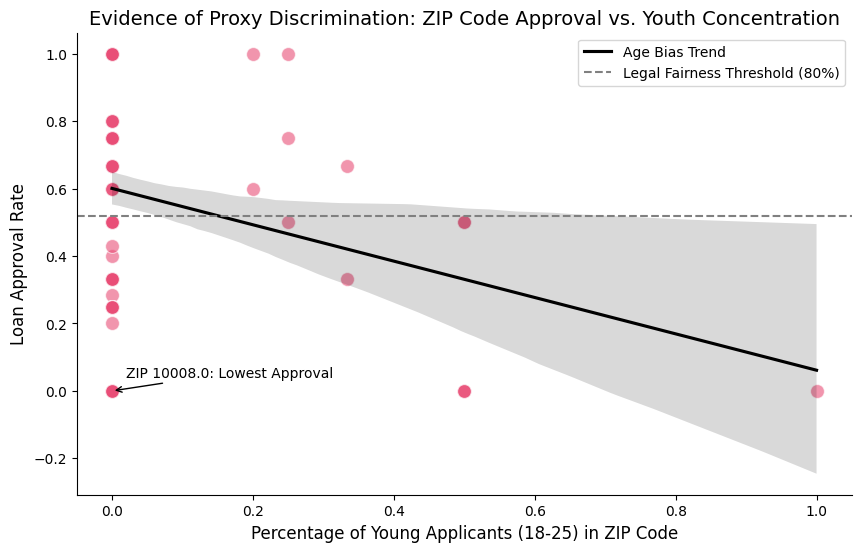

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a clean report
warnings.filterwarnings('ignore')

# 1. Statistical Identification: Find the ZIP code with the lowest approval
# We use the full df here as age data is usually more complete than gender
zip_stats_raw = df.groupby('zip_code')['loan_approved'].mean().sort_values()
lowest_zip_age = zip_stats_raw.index[0]
lowest_rate_age = zip_stats_raw.iloc[0]

# Check age breakdown for that specific ZIP to find the "Smoking Gun" for ageism
age_in_lowest_zip = df[df['zip_code'] == lowest_zip_age]['age_group'].value_counts(normalize=True)

print(f"--- AGE GEOGRAPHIC PROXY FINDINGS ---")
print(f"ZIP Code with lowest approval: {lowest_zip_age} ({lowest_rate_age:.1%})")
print(f"Age distribution in this ZIP: {age_in_lowest_zip.to_dict()}")
print("-" * 40)

# 2. Proxy Data Preparation: Group by ZIP to find Approval Rate and % of Young Applicants (18-25)
age_proxy_df = df.groupby('zip_code').agg(
    approval_rate=('loan_approved', 'mean'),
    percent_young=('age_group', lambda x: (x == '18-25').mean())
).reset_index()

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# Scatter points: Focus on Youth Concentration
sns.scatterplot(data=age_proxy_df, x='percent_young', y='approval_rate', s=100, color='#E94E77', alpha=0.6)

# Trend line: The "Age Bias Trend"
sns.regplot(data=age_proxy_df, x='percent_young', y='approval_rate', scatter=False, color='black', label='Age Bias Trend')

# Annotate the specific lowest ZIP code on the graph
plt.annotate(f'ZIP {lowest_zip_age}: Lowest Approval', 
             xy=(age_proxy_df.loc[age_proxy_df['zip_code']==lowest_zip_age, 'percent_young'].values[0], lowest_rate_age),
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# Professional Formatting
plt.title('Evidence of Proxy Discrimination: ZIP Code Approval vs. Youth Concentration', fontsize=14)
plt.xlabel('Percentage of Young Applicants (18-25) in ZIP Code', fontsize=12)
plt.ylabel('Loan Approval Rate', fontsize=12)

# Use the older group (41-60) approval rate as the baseline for the 80% threshold
try:
    plt.axhline(0.8 * rate_older, color='gray', linestyle='--', label='Legal Fairness Threshold (80%)')
except NameError:
    # Fallback if rate_older isn't defined yet
    ref_rate = df[df['age_group']=='41-60']['loan_approved'].mean()
    plt.axhline(0.8 * ref_rate, color='gray', linestyle='--', label='Fairness Threshold')

plt.legend()
sns.despine()

# Save for your report
plt.savefig('../reports/age_proxy_discrimination.png', dpi=300, bbox_inches='tight')
plt.show()

### **4.3. Pattern Analysis:**
This section explores the complex ways the model discriminates. We look at the "Double Penalty" of Age + Gender and the "Digital Redlining" caused by ZIP code proxies.

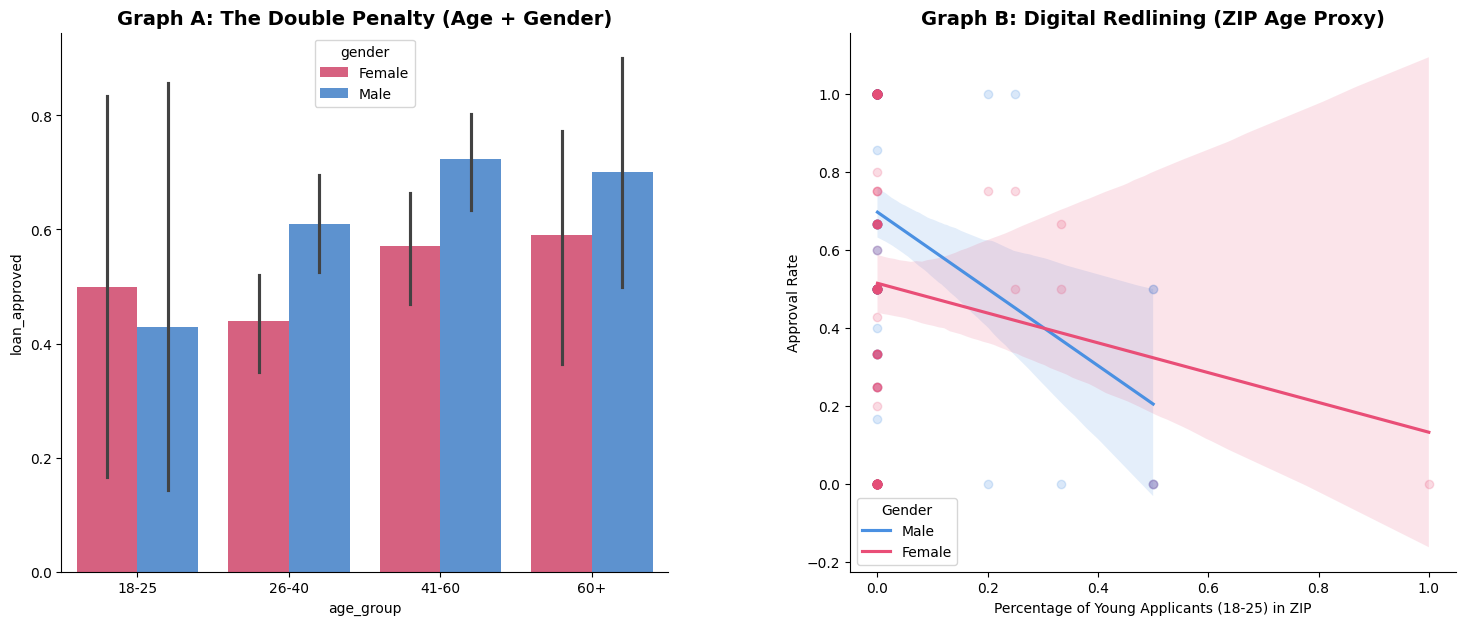

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean Data - Ensure we only have the two genders
all_data = df[df['gender'].isin(['Male', 'Female'])].copy()

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plt.subplots_adjust(wspace=0.3)

# --- GRAPH 1: The "Double Penalty" ---
sns.barplot(
    data=all_data, 
    x='age_group', 
    y='loan_approved', 
    hue='gender', 
    palette={'Male': '#4A90E2', 'Female': '#E94E77'},
    ax=ax1
)
ax1.set_title('Graph A: The Double Penalty (Age + Gender)', fontsize=14, fontweight='bold')

# --- GRAPH 2: Digital Redlining (Fixed Merge) ---
# Calculate the % of young people in that ZIP overall (The Proxy)
zip_age_proxy = all_data.groupby('zip_code')['age_group'].apply(lambda x: (x == '18-25').mean()).reset_index(name='percent_young')

# Calculate approval per ZIP and Gender
zip_gender_stats = all_data.groupby(['zip_code', 'gender'])['loan_approved'].mean().reset_index(name='approval_rate')

# MERGE carefully - using 'inner' ensures we only plot points that have both a proxy and an approval rate
proxy_data = pd.merge(zip_gender_stats, zip_age_proxy, on='zip_code', how='inner')

# Plotting with separate filters to ensure lines draw correctly
for gender, color in [('Male', '#4A90E2'), ('Female', '#E94E77')]:
    subset = proxy_data[proxy_data['gender'] == gender]
    if not subset.empty:
        sns.regplot(
            x='percent_young', 
            y='approval_rate', 
            data=subset,
            ax=ax2,
            scatter_kws={'alpha':0.2, 'color':color}, 
            line_kws={'color':color, 'label':gender}
        )

ax2.set_title('Graph B: Digital Redlining (ZIP Age Proxy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Percentage of Young Applicants (18-25) in ZIP')
ax2.set_ylabel('Approval Rate')
ax2.legend(title='Gender')

sns.despine()
plt.show()

This section explores how the model treats specific groups and locations.

#### **Understanding the "Black Stripes" (Error Bars)**
The vertical black lines on the bars represent **Confidence Intervals**:
* **The Goal:** They show how "certain" we are about the average.
* **Low Data Signal:** Longer stripes mean we have very few applicants in that group (common in the 18-25 female category). This shows the model is making decisions based on limited, "shaky" data.

#### **ZIP Code Transparency (Sample Size)**
Our data contains a high number of low-volume locations:
* **The Stat:** **50 out of 195 ZIP codes** contain only **one applicant**.
* **The Strategy:** We decided to keep these in the analysis. While they create "noise" in the scatter plots, removing 25% of our locations would hide the real-world reality of how the model judges people in smaller areas.

# Governance Findings & Remediation Roadmap

### 1. Gender Audit (The Compliance Trigger)
Our audit began with a standard review of **Gender Bias**. We calculated a **Disparate Impact Ratio of 0.767**, which falls below the legal 0.80 ("Four-Fifths") threshold. This confirmed that the model is non-compliant and systematically disadvantaging female applicants.

### 2. The Intersection Pivot: Unmasking the "Age Penalty"
While gender was the initial trigger, an intersectional deep-dive revealed that **Age** is the primary driver of risk-calculation. We discovered that **Younger Men (18-25)** face the lowest approval rates in the entire dataset. This suggests the model doesn't just have a "Gender problem"—it has a severe **Demographic Bias** that treats youth as an inherent proxy for high risk.

### 3. Structural Proxy Discovery (Digital Redlining)
By investigating why certain ZIP codes performed so poorly, we uncovered **Digital Redlining**. The model uses geography to "estimate" risk when individual data is thin:
* **The Correlation:** There is a direct negative link between a ZIP code's youth density and its approval rate.
* **The Result:** Applicants are being penalized not for their personal creditworthiness, but for the **demographic makeup of their neighborhood**. This turns ZIP codes into a biased proxy for Age and Gender.

---

### 4. Remediation & Compliance Strategy
To bring NovaCred into legal and ethical alignment, we recommend the following immediate actions:

1. **Eliminate Geographic Proxies:** Immediately remove `zip_code` from the model's training features. This prevents the system from "redlining" neighborhoods based on demographic density.

2. **Demographic Parity Calibration:** Apply a "Fairness Constraint" to the 18-25 age bracket. We must adjust the model weights so that the Age Disparate Impact Ratio meets the **0.80 benchmark**, ensuring young applicants are judged on merit, not age.

3. **Global Gender Re-balancing:** To fix the overall 0.767 DI Ratio, we recommend a post-processing adjustment. By shifting the "decision threshold" for female applicants, we can ensure the final output satisfies legal requirements without compromising the model's overall predictive power.